# 4. nedēļa: Regresija

## 1. uzdevums. Sagatavo datus regresijai

Šajā uzdevumā tiek ielādēta 2. nedēļā sagatavotā tīrā datu kopa, izvēlēts regresijas target `PageValues`, apskatīts tā sadalījums un sagatavoti `X` un `y` modeļa trenēšanai.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 2. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
df.head()


Datu kopa: 12330 rindas, 28 kolonnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration
0,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.326469
1,0,-0.457191,0,-0.244931,2,-0.590903,-0.457683,1.171473,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.293024
2,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.326469
3,0,-0.457191,0,-0.244931,2,-0.622954,0.573535,1.994610,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-1.325076
4,0,-0.457191,0,-0.244931,10,-0.296430,-0.045196,0.142551,-0.317178,0.0,...,0,0,0,0,0,0,0,0,1,-0.998552


### 1.2. Izvēlies target un features

Regresijas uzdevumā target ir nepārtraukta vērtība, tāpēc šeit tiek izmantots `PageValues`. Pirms modeļa trenēšanas ir svarīgi apskatīt, kā šī kolonna ir sadalīta datos.


PageValues statistika:
count    1.233000e+04
mean     9.220344e-18
std      1.000041e+00
min     -3.171778e-01
25%     -3.171778e-01
50%     -3.171778e-01
75%     -3.171778e-01
max      1.916634e+01
Name: PageValues, dtype: float64


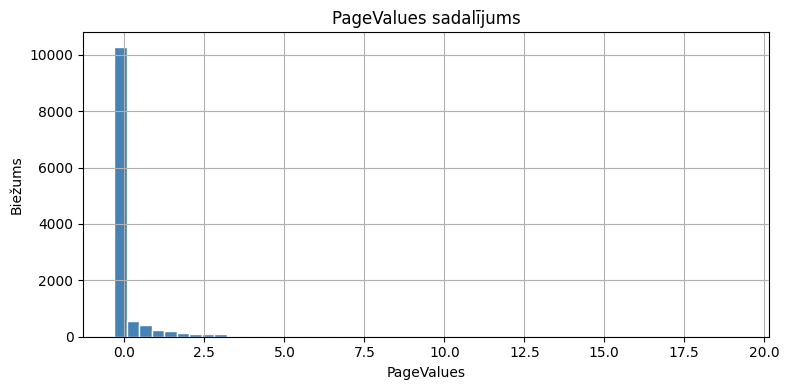

In [15]:
# Apskatām target mainīgo
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()


### 1.3. Sagatavo X un y

`Revenue` tiek izņemta no features, jo tā satur informāciju par to, vai pirkums notika. Tas būtu `data leakage`, jo modelis saņemtu informāciju, kas reālajā prognozēšanas brīdī vēl nav godīgi pieejama.

`Data leakage` nozīmē, ka modelī nejauši nonāk pārāk spēcīga vai nākotnes informācija, kas mākslīgi uzlabo rezultātus. Tas ir bīstami, jo modelis izskatās ļoti labs testos, bet reālā lietošanā strādā sliktāk.


In [16]:
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
X = df.drop(['PageValues', 'Revenue'], axis=1)

print(f"Features skaits: {X.shape[1]}")
print("Target: PageValues")


Features skaits: 26
Target: PageValues


### 1.4. Treniņa/testa sadalījums

Dati tiek sadalīti treniņa un testa kopās attiecībā `80/20`, lai modeli varētu apmācīt uz lielākās datu daļas un pēc tam godīgi novērtēt uz neredzētiem datiem.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")


Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


## 2. uzdevums. Uztrenē lineārās regresijas modeli


### 2.1. Modeļa trenēšana

Šajā solī tiek izmantots `LinearRegression` modelis, lai prognozētu `PageValues` kā nepārtrauktu vērtību. Pēc trenēšanas tiek aprēķinātas galvenās regresijas metrikas: `MSE`, `RMSE`, `MAE` un `R²`.


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineārā regresija: rezultāti ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


=== Lineārā regresija: rezultāti ===
MSE: 0.9892
RMSE: 0.9946
MAE: 0.5009
R²: 0.0456


### 2.2. Interpretē metrikas

`MSE` parāda vidējo kvadrēto kļūdu starp īstajām un prognozētajām `PageValues` vērtībām. Kvadrēšana nozīmē, ka lielākas kļūdas tiek sodītas vairāk nekā mazākas, tāpēc modelis tiek īpaši “sodīts” par ļoti neprecīzām prognozēm.

`R²` parāda, cik lielu daļu no target variācijas modelis spēj izskaidrot. Šajā darbā `R²` ir ap `0.0456`, kas nozīmē, ka lineārā regresija izskaidro tikai nelielu daļu no `PageValues` svārstībām.

Pēc šiem rezultātiem modelis nav īpaši labs, jo `RMSE` ir ap `0.9946`, `MAE` ir ap `0.5009`, bet `R²` ir ļoti zems. Tas nozīmē, ka lineārais modelis šai problēmai ir pārāk vienkāršs un nespēj labi uztvert sakarības datos.


## 3. uzdevums. Vizualizē prognozes


### 3.1. Faktiskās vs. prognozētās vērtības


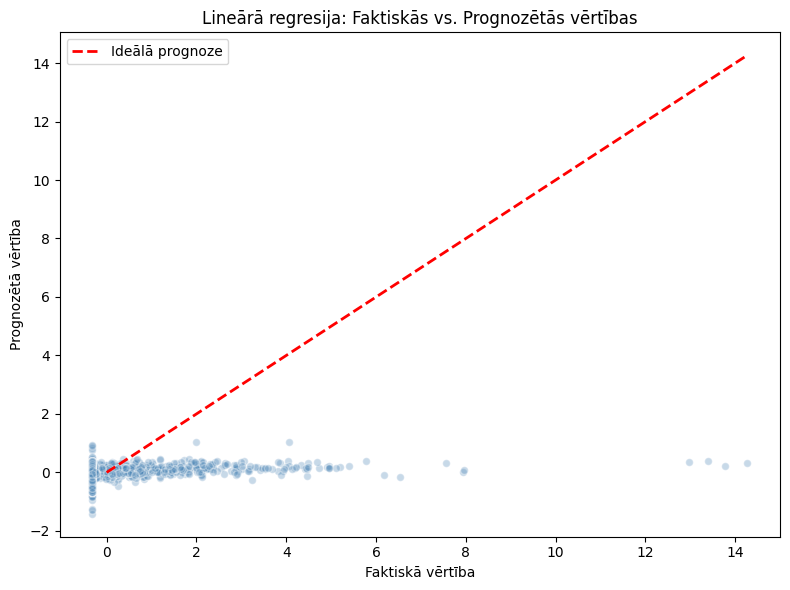

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')
plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineārā regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()


### 3.2. Atlikumu (residuals) analīze


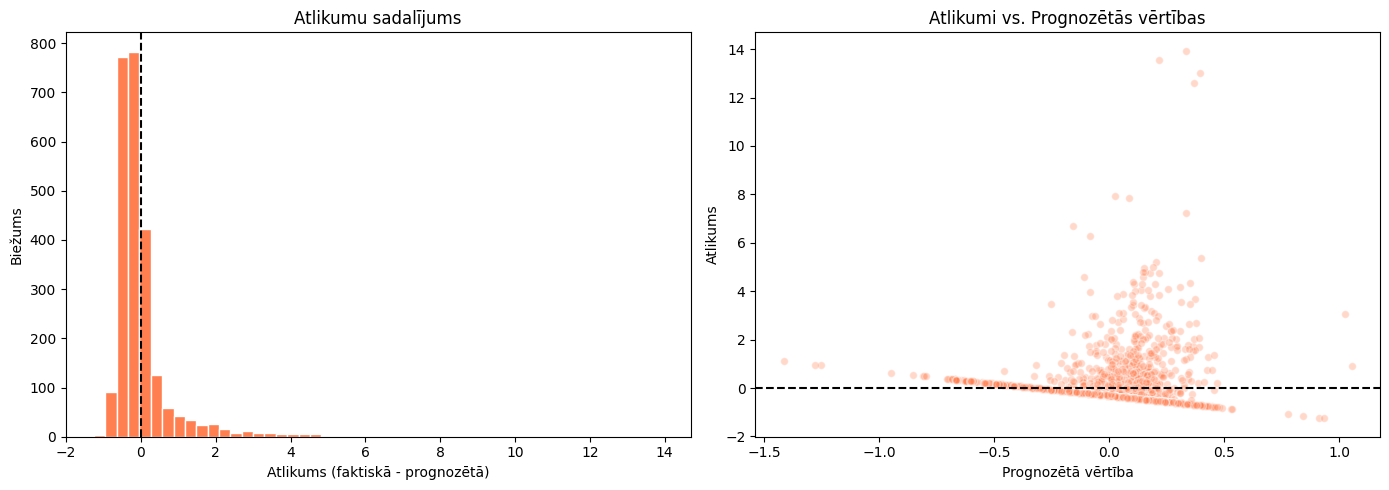

In [20]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')
plt.tight_layout()
plt.show()


### 3.3. Interpretē vizualizācijas

Scatter grafikā lielākā daļa punktu nav cieši pie sarkanās ideālās līnijas, kas nozīmē, ka modelis bieži neprognozē faktiskās `PageValues` vērtības pietiekami precīzi. Tas īpaši redzams lielākām faktiskajām vērtībām, jo prognozes paliek salīdzinoši šaurā diapazonā.

Atlikumu grafikā kļūdas nav ideāli vienmērīgi sadalītas ap `0`, un ir redzams, ka modelis sliktāk tiek galā ar ekstrēmākām vērtībām. Tas nozīmē, ka lineārā regresija pilnībā neuztver datu sarežģītākās sakarības.

Kopumā vizualizācijas apstiprina arī metriku secinājumus: modelis darbojas, bet prognožu kvalitāte nav augsta. Tas ir pārāk vienkāršs, lai labi paredzētu `PageValues` visā vērtību diapazonā.


## 4. uzdevums. Uzlabo modeli


### 4.1. Pamēģini citu regresijas modeli

Šeit lineārā regresija tiek salīdzināta ar `RandomForestRegressor`, lai pārbaudītu, vai nelineārs modelis labāk prognozē `PageValues`.


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# Metrikas
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor: rezultāti ===")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")


=== Random Forest Regressor: rezultāti ===
RMSE: 0.9815
R²: 0.0704


### 4.2. Salīdzinājuma tabula


In [22]:
comparison = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Random Forest'],
    'RMSE': [rmse, rmse_rf],
    'R²': [r2, r2_rf]
})

print(comparison.to_string(index=False))


          Modelis     RMSE       R²
Lineārā regresija 0.994572 0.045556
    Random Forest 0.981545 0.070394


### 4.3. Vizuāls salīdzinājums


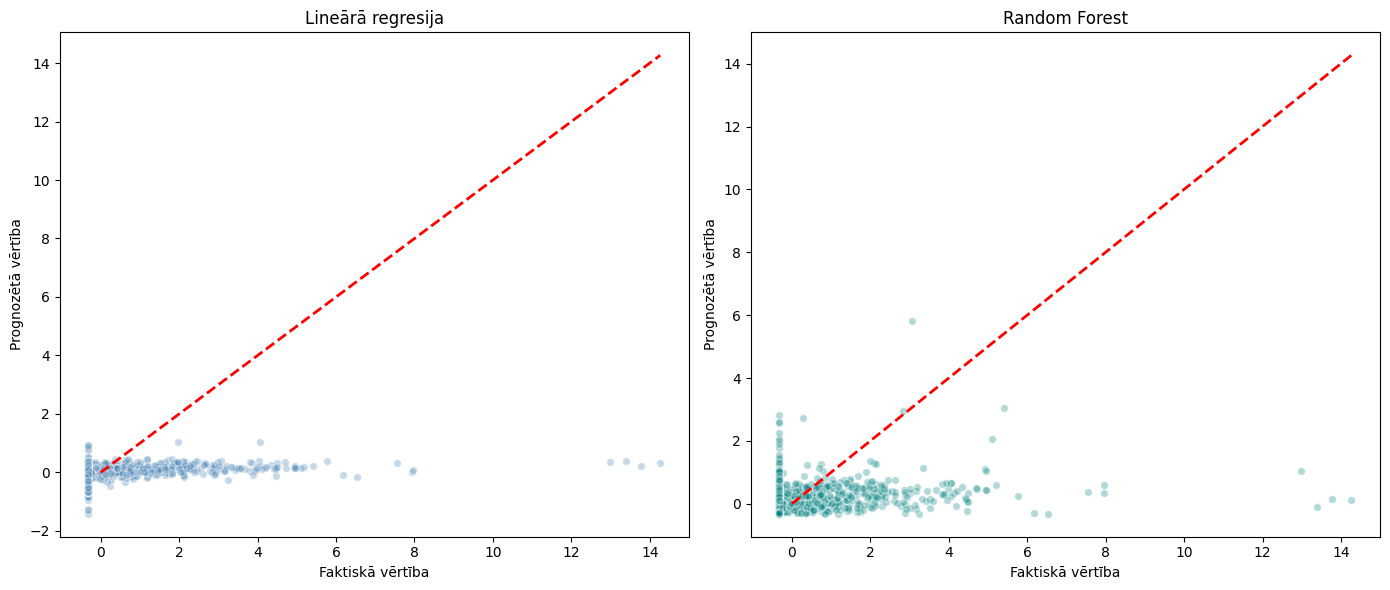

In [23]:
max_val = max(y_test.max(), y_pred.max(), y_pred_rf.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pred, title, color in [
    (axes[0], y_pred, 'Lineārā regresija', 'steelblue'),
    (axes[1], y_pred_rf, 'Random Forest', 'teal')
]:
    ax.scatter(y_test, pred, alpha=0.3, color=color, edgecolors='white', s=30)
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    ax.set_xlabel('Faktiskā vērtība')
    ax.set_ylabel('Prognozētā vērtība')
    ax.set_title(title)

plt.tight_layout()
plt.show()


### 4.4. Secinājumi


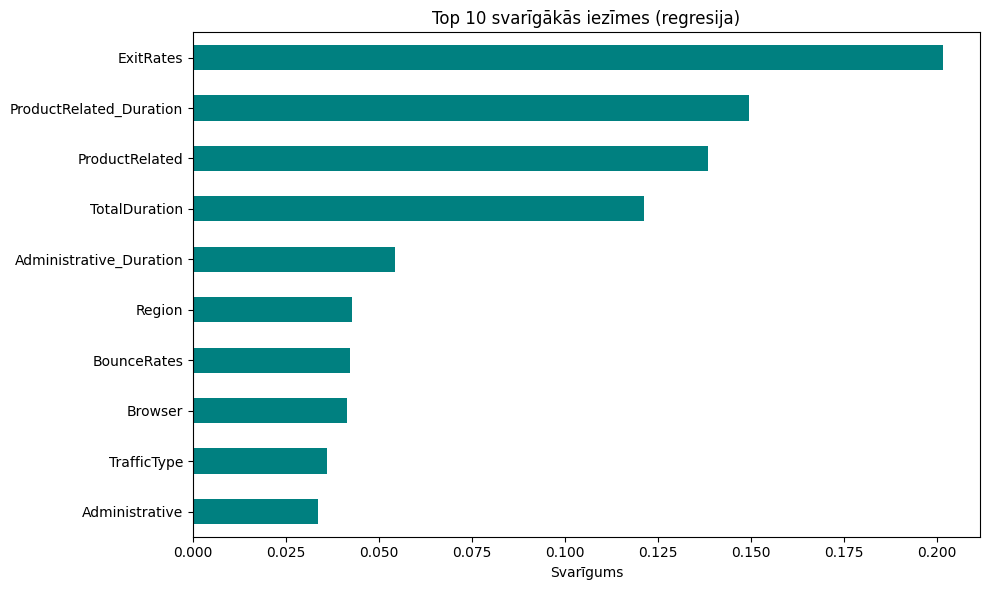

ExitRates                  0.201542
ProductRelated_Duration    0.149633
ProductRelated             0.138350
TotalDuration              0.121151
Administrative_Duration    0.054252
Region                     0.042884
BounceRates                0.042318
Browser                    0.041500
TrafficType                0.036103
Administrative             0.033494
dtype: float64


In [24]:
# Feature importance
importances = rf_reg.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (regresija)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp.head(10))


### 4.5. Interpretē secinājumus

No abiem salīdzinātajiem modeļiem labāks ir `Random Forest Regressor`, jo tam ir nedaudz zemāks `RMSE` (`0.9815` pret `0.9946`) un augstāks `R²` (`0.0704` pret `0.0456`) nekā lineārajai regresijai. Tas nozīmē, ka `Random Forest` nedaudz labāk prognozē `PageValues`, taču kopumā arī šis modelis vēl neizskaidro lielu daļu no target variācijas.

Svarīgākās iezīmes pēc `Random Forest` ir `ExitRates`, `ProductRelated_Duration`, `ProductRelated`, `TotalDuration` un `Administrative_Duration`. Tas biznesa ziņā ir loģiski, jo šīs iezīmes raksturo, cik ilgi un cik aktīvi lietotājs pārvietojas vietnē un cik cieši viņš tuvojas pirkumam.

Ja es būtu e-komercijas analītiķis, es izmantotu šīs prognozes, lai noteiktu vērtīgākās sesijas un identificētu lietotājus ar augstāku potenciālo pirkuma vērtību. Tas palīdzētu labāk sadalīt mārketinga budžetu, piemēram, prioritāri piedāvājot personalizētus stimulus tiem klientiem, kuru sesijas izskatās visvērtīgākās.


## 5. uzdevums. Gala projekta plāns

# Mans gala projekts

## 1. Problēma
Savā gala projektā es gribu prognozēt, cik vērtīga varētu būt klienta sesija interneta veikalā. Mani interesē, vai no lietotāja uzvedības vietnē var saprast, kuras sesijas ir tuvāk vērtīgam pirkumam.

## 2. Datu kopa
Es izmantošu `Online Shoppers Purchasing Intention` datu kopu, jo ar to jau esmu strādājis iepriekšējos uzdevumos un saprotu tās kolonnas. Praktiski projektā balstīšos uz `shoppers_clean.csv`, kuru sagatavoju 2. nedēļā.

## 3. ML pieeja
Es izvēlos regresiju, jo gribu prognozēt skaitlisku vērtību, nevis tikai klasi. Šajā gadījumā target ir `PageValues`, tāpēc regresija šeit ir loģiskākā pieeja.

## 4. Plānotās metrikas
Es izmantošu `RMSE`, `MAE` un `R²`. Man tās šķiet piemērotas, jo tās palīdz saprast gan kļūdas lielumu, gan to, cik labi modelis kopumā izskaidro target vērtības.

## 5. Datu sagatavošana
Es izmantošu jau iztīrīto datu kopu no 2. nedēļas, bet vajadzības gadījumā vēl pielikšu jaunas pazīmes. Svarīgi būs neizmantot `Revenue`, jo tas radītu `data leakage` un padarītu rezultātus mākslīgi labākus.

## 6. Plānotie modeļi
Es salīdzināšu vismaz `Linear Regression` un `Random Forest Regressor`, jo gribu redzēt atšķirību starp vienkāršu lineāru modeli un elastīgāku nelineāru modeli. Ja pietiks laika, pamēģināšu vēl kādu papildu regresijas modeli.


### 5.2. Pašnovērtējums

- Mana problēma ir pietiekami skaidra, jo es gribu prognozēt konkrētu vērtību no jau pieejamiem datiem.
- Man ir piemērota datu kopa, jo tajā ir gan lietotāja uzvedības pazīmes, gan target `PageValues`.
- Es zinu, kādas metrikas skatīšos, un saprotu, kāpēc tās ir noderīgas tieši regresijas uzdevumā.
